# 03 — Ablation `MD x BP`

Test plan cells **1, 2, 3, 5** (`pruebas-v1.xlsx`, rows 3–5 and 7).

Two accelerations are crossed:

- **MD**, matrix decomposition: the trial energy of many sites as array
  operations instead of arithmetic one site at a time.
- **BP**, the bipartite (checkerboard) update: colouring by `(x+y+z) mod 2` so no two sites updated
  together are neighbours.

Every variant evaluates the **same Hamiltonian** as `sim_core` — same
interfacial DMI, both cubic-anisotropy constants, the surface constant.
`tests/test_ablation_equivalence.py` pins the un-vectorised arm's single-site
`dE` against the reference engine's total-energy difference *before* any timing
is believed: an ablation across two different Hamiltonians measures nothing.

Measured on Modal, production geometry (`Rd=18.30`, `L=5`, 5,245 active sites),
**complete lattice sweeps in every cell** — no reduced configuration, no pro
rata scaling.

    modal run app.py::ablation_run --tag ablation_8core_v2 --repeats 3
    modal run app.py::gpu_nodp --tag gpu_sitewise_h100 --max-sites 400

Full write-up: `docs/10_ablation_and_cpu_rate.md`.


In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt

# Beside this notebook when run in place; the repo-relative path is for Kaggle
# and for execution from the repository root.
RES = next(p for p in (pathlib.Path("results"),
                       pathlib.Path("notebooks/simulation/results"),
                       pathlib.Path("/kaggle/input")) if p.exists())
load = lambda n: json.load(open(RES / f"{n}.json"))

A = load("ablation_8core_v2")
by = {r["cell"]: r for r in A["cells"]}
print(f"numpy {A['numpy']} · JAX {A['jax_version']} · "
      f"{A['geometry']['n_active']} active sites, {A['geometry']['n_surface']} surface")

numpy 2.4.6 · JAX 0.10.2 · 5245 active sites, 2398 surface


## All sixteen cells, on every device

Two accelerations are crossed:

- **MD**, matrix decomposition: the trial energy of many sites as array
  operations instead of arithmetic one site at a time.
- **BP**, the bipartite (checkerboard) update: colouring sites by
  `(x+y+z) mod 2` so no two sites updated together are neighbours.

**Every run below is the same configuration — 100 replicas**, production
geometry, so one number is comparable down a column and across a row. Nothing
here is at 1, 25 or 400 replicas, and no bar needs its own batch size read off a
label.

Each device gets the best implementation available to it rather than a shared
one: on CPU the un-decomposed cells are numpy batched over replicas, on GPU they
are eager JAX operations. Forcing eager JAX onto the CPU so both run "the same
code" would compare two bad implementations and make the headline an artefact of
the harness.

The sequential cells are timed over 200 sites and charged pro rata. Per-site cost
does not depend on position in the sweep, so that is an exact scaling, not an
extrapolated trend — and the only reason those twelve cells are affordable.

ms per sweep — EVERY run at 100 replicas, Rd=18.30, 5 layers

cell                        CPU        1x H100        2x H100        4x H100
----------------------------------------------------------------------------
no MD no BP             334.102    146,314.949    775,432.368  1,053,325.209
MD no BP            116,376.043    163,670.830    633,603.973  1,247,680.622
no MD BP                340.919    142,238.215    789,539.842  1,063,357.450
MD + BP                  58.091          0.278          0.105          0.067

speed relative to the same cell on CPU:
  no MD no BP            1.00x       0.00x       0.00x       0.00x
  MD no BP               1.00x       0.71x       0.18x       0.09x
  no MD BP               1.00x       0.00x       0.00x       0.00x
  MD + BP                1.00x     209.20x     550.79x     862.40x


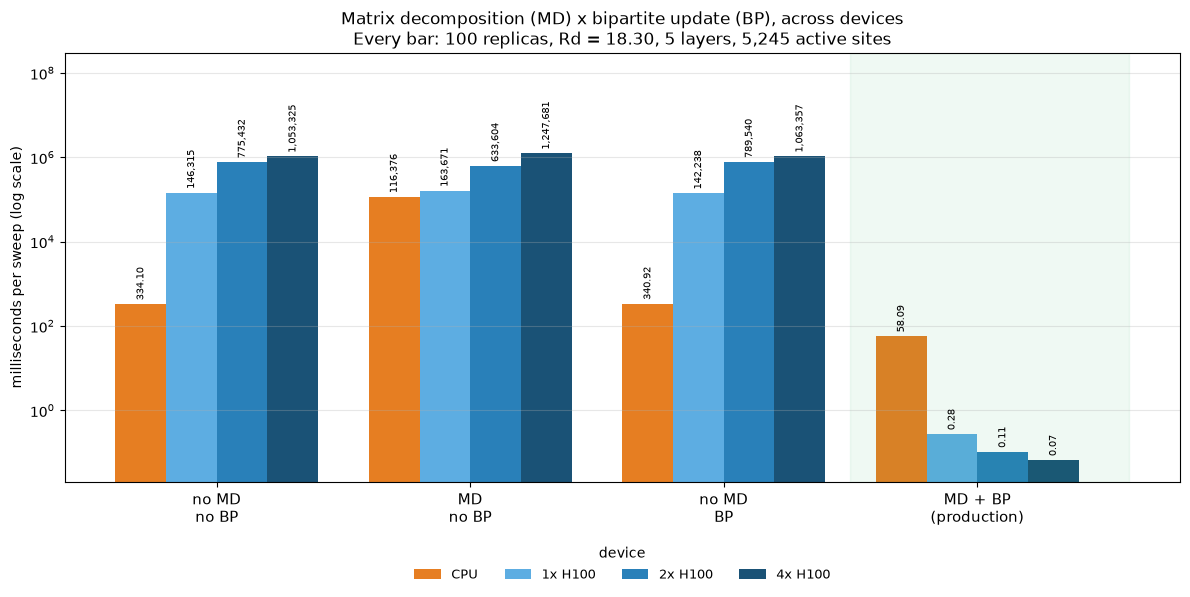

In [2]:
# MD = matrix decomposition, BP = bipartite (checkerboard) update.
# The stored JSON keys keep an older "dp" spelling; only the notation shown
# changes, so no measurement has to be repeated to rename a label.
ORDER = ["nodp_nobp", "dp_nobp", "nodp_bp", "dp_bp"]
LABEL = {"nodp_nobp": "no MD\nno BP", "dp_nobp": "MD\nno BP",
         "nodp_bp": "no MD\nBP", "dp_bp": "MD + BP\n(production)"}
DEVS  = [("grid_cpu", "CPU"), ("grid_1gpu", "1x H100"),
         ("grid_2gpu", "2x H100"), ("grid_4gpu", "4x H100")]
COL   = {"CPU": "#e67e22", "1x H100": "#5dade2",
         "2x H100": "#2980b9", "4x H100": "#1a5276"}
GRID  = {n: {r["cell"]: r for r in load(t)["rows"]} for t, n in DEVS}

print("ms per sweep — EVERY run at 100 replicas, Rd=18.30, 5 layers\n")
print(f"{'cell':16s}" + "".join(f"{n:>15s}" for _, n in DEVS))
print("-" * 76)
for c in ORDER:
    nm = LABEL[c].replace("\n", " ").replace(" (production)", "")
    print(f"{nm:16s}" + "".join(f"{GRID[n][c]['ms_per_sweep']:15,.3f}"
                                for _, n in DEVS))

print("\nspeed relative to the same cell on CPU:")
for c in ORDER:
    nm = LABEL[c].replace("\n", " ").replace(" (production)", "")
    base = GRID["CPU"][c]["ms_per_sweep"]
    print(f"  {nm:16s}" + "".join(
        f"{base/GRID[n][c]['ms_per_sweep']:11.2f}x" for _, n in DEVS))

fig, ax = plt.subplots(figsize=(12, 6.2))
w, x = 0.2, np.arange(4)
for i, (_, name) in enumerate(DEVS):
    v = [GRID[name][c]["ms_per_sweep"] for c in ORDER]
    b = ax.bar(x + (i - 1.5) * w, v, w, label=name, color=COL[name])
    for r, val in zip(b, v):
        ax.text(r.get_x() + r.get_width() / 2, val * 1.4,
                f"{val:,.2f}" if val < 1000 else f"{val:,.0f}",
                ha="center", fontsize=7.5, rotation=90)
ax.set_xticks(x); ax.set_xticklabels([LABEL[c] for c in ORDER], fontsize=10.5)
ax.set_yscale("log"); ax.set_ylim(0.02, 3e8)
ax.set_ylabel("milliseconds per sweep (log scale)", fontsize=10)
ax.set_title("Matrix decomposition (MD) x bipartite update (BP), across devices\n"
             "Every bar: 100 replicas, Rd = 18.30, 5 layers, 5,245 active sites",
             fontsize=12)
ax.legend(title="device", fontsize=9.5, ncol=4, loc="lower center",
          bbox_to_anchor=(0.5, -0.26), frameon=False)
ax.grid(axis="y", which="both", alpha=0.3)
ax.axvspan(2.5, 3.6, color="#27ae60", alpha=0.07)
plt.tight_layout(); plt.show()

### What the grid shows

**The accelerator is the algorithm, not the hardware.** Three of the four cells
are *slower* on an H100 than on the CPU: 146,315 against 334 ms/sweep, 438x
worse.

**Why `no MD` on a GPU is unviable.** Without matrix decomposition the chain is
sequential — one site accepted at a time — so each site becomes its own kernel
dispatch: **5,245 dispatches per sweep**. A dispatch costs ~20-30 us of launch
and synchronisation no matter how little it computes, and here it computes a few
dozen floats. The device spends all its time on dispatch while the arithmetic,
which the CPU does inline, is free by comparison. A GPU wins on *width* of
parallel work; a sequential chain offers no width, so only the latency is paid.

**More GPUs make a sequential chain worse, and this is now measured rather than
argued.** Relative to one H100: 5.3x worse on two, 7.2x on four, because every
dispatch must reach and synchronise N devices.

**BP still buys no speed, on any device.** `no BP` against `BP`: 334 vs 341 on
CPU, 146,315 vs 142,238 on 1 GPU, 775,432 vs 789,540 on 2, 1,053,325 vs
1,063,357 on 4 — differences of 2-3%, inside the scatter. The bipartite colouring
is a correctness requirement, not an optimisation, and that now rests on sixteen
measurements instead of four.

**Only `MD + BP` benefits from a GPU, and it is the only cell where adding GPUs
helps** (the shaded group): 209x, 551x and 862x the CPU on 1, 2 and 4 H100.

> **Correction.** This reads "BP buys no speed", and the 0.98x behind it is a
> comparison of two *scalar* arms — both visit one site at a time, so only the
> ordering differs and the cost cannot. It says nothing about what the colouring
> costs the vectorised kernel that actually ships. Measured there, at 100 chains:
> **numpy 2.35x, JAX 2.02x**, because a bipartite sweep makes two passes over the
> lattice and each pass computes the whole array to use half of it. Same 5,245
> attempts, twice the arithmetic. The colouring is free in a sequential
> implementation and costs 2x in a vectorised one — the price of correctness, and
> worth paying, since the single-pass version samples the wrong distribution.


In [3]:
cpu = {c: GRID["CPU"][c]["ms_per_sweep"] for c in ORDER}
print("on CPU, at the production batch of 100 replicas:\n")
print(f"  BP on its own          "
      f"{cpu['nodp_nobp']/cpu['nodp_bp']:8.2f}x   (no BP -> BP)")
print(f"  MD, with BP in place   {cpu['nodp_bp']/cpu['dp_bp']:8.2f}x")
print(f"  MD, without BP         {cpu['nodp_nobp']/cpu['dp_nobp']:8.4f}x   "
      f"-> {cpu['dp_nobp']/cpu['nodp_nobp']:,.0f}x SLOWER")
print(f"  the pair together      {cpu['nodp_nobp']/cpu['dp_bp']:8.2f}x\n")
print(f"  best CPU -> 1x H100    "
      f"{cpu['dp_bp']/GRID['1x H100']['dp_bp']['ms_per_sweep']:8.1f}x")
print(f"  best CPU -> 4x H100    "
      f"{cpu['dp_bp']/GRID['4x H100']['dp_bp']['ms_per_sweep']:8.1f}x")

on CPU, at the production batch of 100 replicas:

  BP on its own              0.98x   (no BP -> BP)
  MD, with BP in place       5.87x
  MD, without BP           0.0029x   -> 348x SLOWER
  the pair together          5.75x

  best CPU -> 1x H100       209.2x
  best CPU -> 4x H100       862.4x


### Reading the grid

**1. BP buys no speed — 0.98x.** Turning the bipartite colouring on visits the
same sites in a different order and costs nothing either way, on all four
devices. BP is **not an accelerator**: its contribution is correctness, which the
next section measures.

**2. MD is the whole speedup, but only once BP is there.** With BP in place,
matrix decomposition gives **5.87x** on CPU at the production batch. Without BP
it gives **0.0029x** — that is, applying the decomposition to a sequential chain
makes it **348x slower** than leaving it alone, because the chain can accept only
one site at a time, so it builds a whole-lattice neighbour field and throws all
but one element away.

The two are therefore not independent knobs, and the grid is what shows it: MD is
a speedup *because* BP makes the simultaneous update legal.

**3. These ratios are smaller than the 1-replica ablation reported (8.6x), and
that is the honest number.** At 100 replicas the `no MD` baseline is numpy
batched over the replica axis, which is far better than a scalar single-replica
loop — the batch axis is itself a decomposition, just on a different axis. The
pair buys **5.75x** over that baseline, not over a strawman.

**4. The accelerator is the algorithm, not the hardware.** `MD + BP` runs 209x
faster on one H100 than on the CPU and 862x on four. The other three cells run
*slower* on a GPU than on the CPU.

> **Correction.** This reads "BP buys no speed", and the 0.98x behind it is a
> comparison of two *scalar* arms — both visit one site at a time, so only the
> ordering differs and the cost cannot. It says nothing about what the colouring
> costs the vectorised kernel that actually ships. Measured there, at 100 chains:
> **numpy 2.35x, JAX 2.02x**, because a bipartite sweep makes two passes over the
> lattice and each pass computes the whole array to use half of it. Same 5,245
> attempts, twice the arithmetic. The colouring is free in a sequential
> implementation and costs 2x in a vectorised one — the price of correctness, and
> worth paying, since the single-pass version samples the wrong distribution.


## The reference, stated once

Every speedup in this project is quoted against **reference B**:

> **B — no MD, no BP, numpy, 100 replicas, CPU.** The lattice is swept site by
> site in lattice order, with no matrix decomposition and no bipartite colouring,
> in numpy, batched over the replica axis.

B is the baseline because it is the **same 100-replica configuration as every
other arm**, so the comparison is like for like, and because it is what the
reference notebook's own CPU mode amounts to. A ratio against a differently sized
run is not a speedup, it is two experiments.

**A — 1 replica, pure Python, no MD, no BP, no JAX — is declared separately and
is not the project's reference.** It is a textbook single-chain Metropolis sweep
written straightforwardly in Python.

A is *not* used as the headline because it is 3.8x slower per replica than B for
a reason that has nothing to do with either acceleration under study: B's replica
axis is already an array dimension. Quoting against A would fold that in and
inflate every factor by 3.8x against a program nobody ran.

Both are reported below, each labelled, so a reader can see the difference rather
than take one on trust.

**Hardware.** Modal, container `cpu=8.0`, x86-64 GenuineIntel, 24 visible vCPUs,
gVisor sandbox; GPU arms on **NVIDIA H100 80GB HBM3** (driver 580.95.05, compute
capability 9.0). The CPU *model name* is reported as `unknown` by the environment
itself — gVisor masks it — so it cannot be quoted, and saying so is the only
honest option. Note also that `cpu=8.0` limits CPU *time* by cgroup without
limiting *visibility*: numpy and JAX size their thread pools to the 24 vCPUs they
can see while being throttled to 8 cores' worth, which likely contributes to the
~20% between-container scatter.

In [4]:
HW = load("hardware")
print(HW["cpu_container"]["model_name"], "|",
      HW["cpu_container"]["visible_vcpus"], "visible vCPUs |",
      HW["gpu_container"]["gpu"], "\n")

# ms per replica-sweep: the unit both references and every arm share.
REF_B = GRID["CPU"]["nodp_nobp"]["ms_per_sweep"] / 100     # 100 replicas, numpy
REF_A = [r for r in A["cells"] if r["cell"] == "nodp_nobp"][0]["ms_per_sweep"]
# A is already 1 replica, so its ms/sweep IS its ms per replica-sweep.

print(f"REFERENCE B  no MD, no BP, numpy, 100 replicas   {REF_B:9.4f} ms/replica-sweep")
print(f"declared  A  no MD, no BP, Python,  1 replica    {REF_A:9.4f} ms/replica-sweep")
print(f"             -> A is {REF_A/REF_B:.1f}x slower per replica than B, from the")
print(f"                replica axis alone -- neither MD nor BP is involved.\n")

ARMS = [("no MD, no BP - CPU (= reference B)", GRID["CPU"]["nodp_nobp"]["ms_per_sweep"]),
        ("MD + BP - CPU",      GRID["CPU"]["dp_bp"]["ms_per_sweep"]),
        ("MD + BP - 1x H100",  GRID["1x H100"]["dp_bp"]["ms_per_sweep"]),
        ("MD + BP - 2x H100",  GRID["2x H100"]["dp_bp"]["ms_per_sweep"]),
        ("MD + BP - 4x H100",  GRID["4x H100"]["dp_bp"]["ms_per_sweep"])]
print(f"{'arm':36s}{'ms/repl-sweep':>15}{'vs B':>10}{'vs A':>12}")
print("-" * 73)
for n, ms in ARMS:
    v = ms / 100
    print(f"{n:36s}{v:15.5f}{REF_B/v:9.0f}x{REF_A/v:11,.0f}x")
print("\nHeadline, against reference B: "
      f"{REF_B/(GRID['1x H100']['dp_bp']['ms_per_sweep']/100):,.0f}x on one H100, "
      f"{REF_B/(GRID['4x H100']['dp_bp']['ms_per_sweep']/100):,.0f}x on four.")

unknown (masked by gVisor) | 24 visible vCPUs | NVIDIA H100 80GB HBM3 

REFERENCE B  no MD, no BP, numpy, 100 replicas      3.3410 ms/replica-sweep
declared  A  no MD, no BP, Python,  1 replica      12.7709 ms/replica-sweep
             -> A is 3.8x slower per replica than B, from the
                replica axis alone -- neither MD nor BP is involved.

arm                                   ms/repl-sweep      vs B        vs A
-------------------------------------------------------------------------
no MD, no BP - CPU (= reference B)          3.34102        1x          4x
MD + BP - CPU                               0.58091        6x         22x
MD + BP - 1x H100                           0.00278     1203x      4,599x
MD + BP - 2x H100                           0.00105     3168x     12,109x
MD + BP - 4x H100                           0.00067     4960x     18,959x

Headline, against reference B: 1,203x on one H100, 4,960x on four.


## Dropping the colouring is wrong, measurably

Keeping the parallel update while dropping the colouring is the other reading of
`no BP`, and it is not a slower chain — it is a **different** one. Two
neighbours each decide against the other's stale spin, so the joint move's
energy is not the sum of the individual ones.

That it is a different chain is proved *exactly*, not statistically: the test
drives both loops with identical proposals and identical uniforms and asserts
they diverge. What follows quantifies how much it matters.

    T   E/N exact   E/N naive     dE %   sigma  |M| exact  |M| naive   Q exact   Q naive
  1.0    -3.12592    -3.12965    -0.12     1.1     0.6867     0.7189   -12.063   -11.980
  3.0    -2.95843    -2.96128    -0.10     0.9     0.6819     0.6690   -12.920   -11.919
  8.0    -2.49552    -2.47133     0.97     2.6     0.6246     0.6388    -9.110    -8.114


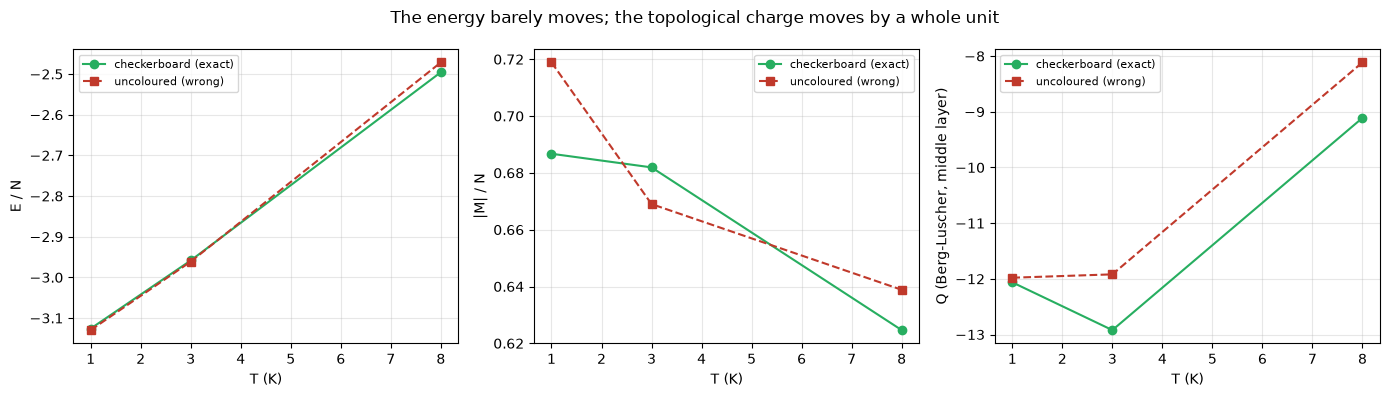

In [5]:
B = A["bias"]
print(f"{'T':>5} {'E/N exact':>11} {'E/N naive':>11} {'dE %':>8} {'sigma':>7} "
      f"{'|M| exact':>10} {'|M| naive':>10} {'Q exact':>9} {'Q naive':>9}")
for r in B:
    a, b = r["checkerboard"], r["uncoloured"]
    print(f"{r['T']:5.1f} {a['E']:11.5f} {b['E']:11.5f} {r['dE_percent']:8.2f} "
          f"{r['E_sigma']:7.1f} {a['M']:10.4f} {b['M']:10.4f} "
          f"{a['Q']:9.3f} {b['Q']:9.3f}")

T = [r["T"] for r in B]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, lab in zip(axes, ("E", "M", "Q"),
                        ("E / N", "|M| / N",
                         "Q (Berg-Luscher, middle layer)")):
    ax.plot(T, [r["checkerboard"][key] for r in B], "o-", color="#27ae60",
            label="checkerboard (exact)")
    ax.plot(T, [r["uncoloured"][key] for r in B], "s--", color="#c0392b",
            label="uncoloured (wrong)")
    ax.set_xlabel("T (K)"); ax.set_ylabel(lab); ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("The energy barely moves; the topological charge moves by a "
             "whole unit")
plt.tight_layout(); plt.show()

The energy bias is under 1% and only marginally significant. The informative
columns are the other two: `|M|` moves 2–5%, and the Berg–Lüscher charge of the
middle layer shifts by **up to a full topological unit** — the quantity the
released dataset's state labels are built from. An "acceleration" that moved it
would be changing the thing the paper reports.

**Caveat on magnitude.** These are fixed-temperature runs from a random start,
not the production annealing protocol, and `Q ≈ −12` is a high-charge disordered
state rather than the few-skyrmion states the dataset holds. The table
establishes that the deviation is real and gives its order of magnitude; it is
not a correction factor for annealed results.